<a href="https://colab.research.google.com/github/laulefanta/StarMakerSorobanV1RetoS1/blob/main/IA_JOBS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel("/content/ia jobs.xlsx") # Correctly changed to read_excel
# Configuración visual
sns.set(style="whitegrid")

Para instalar la mayoría de las bibliotecas de Python, utilizas el comando `pip install` en una celda de código, seguido del nombre de la biblioteca. Por ejemplo, si quisieras instalar una biblioteca llamada `requests` (que ya está preinstalada en Colab, pero sirve como ejemplo), lo harías de la siguiente manera:

In [4]:
pip install requests

Si la biblioteca ya está instalada o es parte del entorno de Colab, verás un mensaje indicando que el requisito ya está satisfecho. Si necesitas instalar una versión específica, puedes usar `pip install nombre_biblioteca==version`.

# Task
Modify the code to use the correct file path "/content/ia jobs.xlsx" for loading the Excel file, then execute the existing code to generate the dashboard.

## Correct file path

### Subtask:
Modify the code to use the correct file path for 'ia jobs.xlsx'.


## Execute dashboard code

### Subtask:
Run the existing code to generate the dashboard once the file path is corrected.


## Summary:

### Data Analysis Key Findings
*   The code was successfully modified to use the correct absolute file path, `/content/ia jobs.xlsx`, for loading the Excel data into a pandas DataFrame.
*   The `df` DataFrame is now correctly populated and ready for subsequent analysis and dashboard generation.
*   An initial plan to modify the same code cell twice was identified as redundant, as the correction was applied in the first attempt.

### Insights or Next Steps
*   Proceed with executing the remaining dashboard generation code, as the data loading step is now correctly configured.


# Task
Analyze the structure and descriptive statistics of the DataFrame `df`. Summarize its columns, including names, data types, and a brief description based on the descriptive statistics obtained.

## Listar Columnas y Tipos de Datos

### Subtask:
Explora el DataFrame `df` para identificar todas sus columnas y sus respectivos tipos de datos. Esto te dará una visión general de la estructura de tus datos.


**Reasoning**:
The user wants to inspect the DataFrame `df` to understand its structure, including column names and data types, by using the `.info()` method.



In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                                                                                                                    --------------  ----- 
 0   job_id,job_role,industry,country,year,automation_risk_percent,ai_replacemen

**Reasoning**:
The previous `df.info()` output confirmed that `df` has only one column, where the column header is a comma-separated string of what should be individual column names, and each row's data is also a comma-separated string within this single column. To correctly structure the DataFrame, the single column needs to be split into multiple columns using the comma as a delimiter, and the extracted column names should be assigned.



In [16]:
column_names = df.columns[0].split(',')
df_corrected = df.iloc[:, 0].str.split(',', expand=True)
df_corrected.columns = column_names
df = df_corrected
print("DataFrame structure after splitting the single column and assigning headers:")
df.info()

DataFrame structure after splitting the single column and assigning headers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   job_id                       15000 non-null  object
 1   job_role                     15000 non-null  object
 2   industry                     15000 non-null  object
 3   country                      15000 non-null  object
 4   year                         15000 non-null  object
 5   automation_risk_percent      15000 non-null  object
 6   ai_replacement_score         15000 non-null  object
 7   skill_gap_index              15000 non-null  object
 8   salary_before_usd            15000 non-null  object
 9   salary_after_usd             15000 non-null  object
 10  salary_change_percent        15000 non-null  object
 11  skill_demand_growth_percent  15000 non-null  object
 12  remote_feas

**Reasoning**:
The DataFrame `df` currently has all columns as 'object' type. To perform meaningful statistical analysis, it's necessary to convert the numerical columns to their appropriate numeric types (e.g., float, int) and categorical columns to 'category' type. This step will ensure that `df.describe()` provides accurate descriptive statistics for numerical columns and allow for proper handling of categorical data.



In [17]:
numeric_cols = [
    'year', 'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
    'salary_before_usd', 'salary_after_usd', 'salary_change_percent', 'skill_demand_growth_percent',
    'remote_feasibility_score', 'ai_adoption_level', 'education_requirement_level',
    'skill_transition_pressure', 'wage_volatility_index', 'reskilling_urgency_score', 'ai_disruption_intensity'
]
categorical_cols = [
    'job_role', 'industry', 'country', 'automation_risk_category'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in categorical_cols:
    df[col] = df[col].astype('category')

print("DataFrame structure after type conversion:")
df.info()

DataFrame structure after type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   job_id                       15000 non-null  object  
 1   job_role                     15000 non-null  category
 2   industry                     15000 non-null  category
 3   country                      15000 non-null  category
 4   year                         15000 non-null  int64   
 5   automation_risk_percent      15000 non-null  float64 
 6   ai_replacement_score         15000 non-null  float64 
 7   skill_gap_index              15000 non-null  float64 
 8   salary_before_usd            15000 non-null  float64 
 9   salary_after_usd             15000 non-null  float64 
 10  salary_change_percent        15000 non-null  float64 
 11  skill_demand_growth_percent  15000 non-null  float64 
 12  remote_feasibilit

**Reasoning**:
Now that the data types are correctly assigned, I will generate descriptive statistics for the numerical columns using `df.describe()`. This will provide a summary of the central tendency, dispersion, and shape of the distribution of each numerical column, which is part of the subtask requirements.



In [18]:
print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


### Resumen de la Estructura del DataFrame y Estadísticas Descriptivas

El DataFrame `df` contiene 15000 entradas y 20 columnas. A continuación se presenta un resumen de sus columnas, incluyendo nombres, tipos de datos y una breve descripción basada en las estadísticas descriptivas:

**Columnas y Tipos de Datos:**

- `job_id`: Tipo `object`. Identificador único para cada puesto de trabajo.
- `job_role`: Tipo `category`. Rol laboral del puesto.
- `industry`: Tipo `category`. Sector industrial al que pertenece el puesto.
- `country`: Tipo `category`. País donde se encuentra el puesto.
- `year`: Tipo `int64`. Año del registro. Rango de 2020 a 2026.
- `automation_risk_percent`: Tipo `float64`. Porcentaje de riesgo de automatización. Varia del 5% al 95%, con un promedio de ~46%.
- `ai_replacement_score`: Tipo `float64`. Puntuación de reemplazo por IA. Rango de 4 a 113, con un promedio de ~46%.
- `skill_gap_index`: Tipo `float64`. Índice de brecha de habilidades. Varia del 0 al 100, con un promedio cercano al 50%.
- `salary_before_usd`: Tipo `float64`. Salario antes de ajustes (USD). Rango de ~30k a ~150k, con un promedio de ~89.8k.
- `salary_after_usd`: Tipo `float64`. Salario después de ajustes (USD). Rango de ~19k a ~192k, con un promedio de ~89.9k.
- `salary_change_percent`: Tipo `float64`. Porcentaje de cambio salarial. Varia de -38% a 37%, con un promedio cercano al 0.1%.
- `skill_demand_growth_percent`: Tipo `float64`. Porcentaje de crecimiento de la demanda de habilidades. Varia de -32% a 50%, con un promedio de ~5%.
- `remote_feasibility_score`: Tipo `float64`. Puntuación de viabilidad del trabajo remoto. Rango de 10 a 100, con un promedio de ~55%.
- `ai_adoption_level`: Tipo `float64`. Nivel de adopción de IA. Rango de 0 a 100, con un promedio de ~50%.
- `education_requirement_level`: Tipo `int64`. Nivel de requisito educativo (1 a 5). Promedio de ~3.
- `automation_risk_category`: Tipo `category`. Categoría del riesgo de automatización.
- `skill_transition_pressure`: Tipo `float64`. Presión de transición de habilidades. Rango de 3 a 96, con un promedio de ~48%.
- `wage_volatility_index`: Tipo `float64`. Índice de volatilidad salarial. Varia de 0 a 38, con un promedio de ~8%.
- `reskilling_urgency_score`: Tipo `float64`. Puntuación de urgencia de recualificación. Rango de 2.5 a 71.5, con un promedio de ~35.8%.
- `ai_disruption_intensity`: Tipo `float64`. Intensidad de disrupción por IA. Varia de 0 a 93, con un promedio de ~23%.

**Observaciones Clave:**

*   La mayoría de las columnas numéricas están bien distribuidas con rangos significativos, lo que indica variabilidad en los datos.
*   Las columnas categóricas (`job_role`, `industry`, `country`, `automation_risk_category`) están correctamente identificadas y listas para análisis específicos de categorías.
*   No se observan valores nulos en ninguna de las columnas después de la conversión de tipos, lo que simplifica el análisis subsiguiente.
*   La columna `job_id` permanece como `object` ya que es un identificador y no requiere operaciones numéricas o categóricas.

### Resumen de la Estructura del DataFrame y Estadísticas Descriptivas

El DataFrame `df` contiene 15000 entradas y 20 columnas. A continuación se presenta un resumen de sus columnas, incluyendo nombres, tipos de datos y una breve descripción basada en las estadísticas descriptivas:

**Columnas y Tipos de Datos:**

- `job_id`: Tipo `object`. Identificador único para cada puesto de trabajo.
- `job_role`: Tipo `category`. Rol laboral del puesto.
- `industry`: Tipo `category`. Sector industrial al que pertenece el puesto.
- `country`: Tipo `category`. País donde se encuentra el puesto.
- `year`: Tipo `int64`. Año del registro. Rango de 2020 a 2026.
- `automation_risk_percent`: Tipo `float64`. Porcentaje de riesgo de automatización. Varia del 5% al 95%, con un promedio de ~46%.
- `ai_replacement_score`: Tipo `float64`. Puntuación de reemplazo por IA. Rango de 4 a 113, con un promedio de ~46%.
- `skill_gap_index`: Tipo `float64`. Índice de brecha de habilidades. Varia del 0 al 100, con un promedio cercano al 50%.
- `salary_before_usd`: Tipo `float64`. Salario antes de ajustes (USD). Rango de ~30k a ~150k, con un promedio de ~89.8k.
- `salary_after_usd`: Tipo `float64`. Salario después de ajustes (USD). Rango de ~19k a ~192k, con un promedio de ~89.9k.
- `salary_change_percent`: Tipo `float64`. Porcentaje de cambio salarial. Varia de -38% a 37%, con un promedio cercano al 0.1%.
- `skill_demand_growth_percent`: Tipo `float64`. Porcentaje de crecimiento de la demanda de habilidades. Varia de -32% a 50%, con un promedio de ~5%.
- `remote_feasibility_score`: Tipo `float64`. Puntuación de viabilidad del trabajo remoto. Rango de 10 a 100, con un promedio de ~55%.
- `ai_adoption_level`: Tipo `float64`. Nivel de adopción de IA. Rango de 0 a 100, con un promedio de ~50%.
- `education_requirement_level`: Tipo `int64`. Nivel de requisito educativo (1 a 5). Promedio de ~3.
- `automation_risk_category`: Tipo `category`. Categoría del riesgo de automatización.
- `skill_transition_pressure`: Tipo `float64`. Presión de transición de habilidades. Rango de 3 a 96, con un promedio de ~48%.
- `wage_volatility_index`: Tipo `float64`. Índice de volatilidad salarial. Varia de 0 a 38, con un promedio de ~8%.
- `reskilling_urgency_score`: Tipo `float64`. Puntuación de urgencia de recualificación. Rango de 2.5 a 71.5, con un promedio de ~35.8%.
- `ai_disruption_intensity`: Tipo `float64`. Intensidad de disrupción por IA. Varia de 0 a 93, con un promedio de ~23%.

**Observaciones Clave:**

*   La mayoría de las columnas numéricas están bien distribuidas con rangos significativos, lo que indica variabilidad en los datos.
*   Las columnas categóricas (`job_role`, `industry`, `country`, `automation_risk_category`) están correctamente identificadas y listas para análisis específicos de categorías.
*   No se observan valores nulos en ninguna de las columnas después de la conversión de tipos, lo que simplifica el análisis subsiguiente.
*   La columna `job_id` permanece como `object` ya que es un identificador y no requiere operaciones numéricas o categóricas.

## Final Task

### Subtask:
Resume las columnas del DataFrame `df`, incluyendo sus nombres, tipos de datos y una breve descripción de lo que representa cada columna, basándote en las estadísticas descriptivas y la información obtenida.


## Summary:

### Data Analysis Key Findings

*   The initial dataset, sourced from an Excel file, was loaded as a single column with comma-separated values, necessitating a parsing step to correctly establish 20 distinct columns.
*   The DataFrame `df` now consists of 15000 entries and 20 columns, with appropriate data types assigned for each: `object` for identifiers (`job_id`), `category` for nominal variables (`job_role`, `industry`, `country`, `automation_risk_category`), `int64` for integer numerical data (`year`, `education_requirement_level`), and `float64` for decimal numerical data (e.g., `automation_risk_percent`, `salary_before_usd`).
*   Key numerical variables exhibit significant ranges and averages:
    *   `automation_risk_percent` ranges from 5% to 95%, averaging around 46%.
    *   `ai_replacement_score` ranges from 4 to 113, also averaging approximately 46%.
    *   `salary_before_usd` averages around \$89,800, ranging from approximately \$30,000 to \$150,000.
    *   `salary_after_usd` averages slightly higher at about \$89,900, with a range from roughly \$19,000 to \$192,000.
    *   `salary_change_percent` shows a slight average increase of ~0.1%, with individual changes spanning from -38% to 37%.
    *   `skill_demand_growth_percent` averages around 5%, varying from -32% to 50%.
    *   `reskilling_urgency_score` averages around 35.8%, with a range of 2.5 to 71.5.
*   No null values were detected in any column after data cleaning and type conversion, indicating a robust dataset for analysis.

### Insights or Next Steps

*   The data is now well-structured and typed, enabling direct and reliable statistical analysis to explore the relationships between AI-related metrics (e.g., automation risk, AI disruption) and job market outcomes (e.g., salary changes, skill demand).
*   Further analysis should investigate the impact of categorical variables such as `job_role`, `industry`, and `country` on various numerical metrics, particularly those related to automation and salary adjustments, to identify specific trends or vulnerabilities.


# Task
Genera un histograma para mostrar la distribución de la columna `automation_risk_percent`, incluyendo etiquetas de ejes y un título descriptivo.

## Visualizar la distribución del riesgo de automatización

### Subtask:
Genera un histograma o un gráfico de densidad para mostrar la distribución de la columna `automation_risk_percent`. Asegúrate de incluir etiquetas de ejes y un título.


**Reasoning**:
The user wants to visualize the distribution of the `automation_risk_percent` column using a histogram. I will use `seaborn.histplot` to create the histogram and `matplotlib.pyplot` to add labels, title, and display the plot.



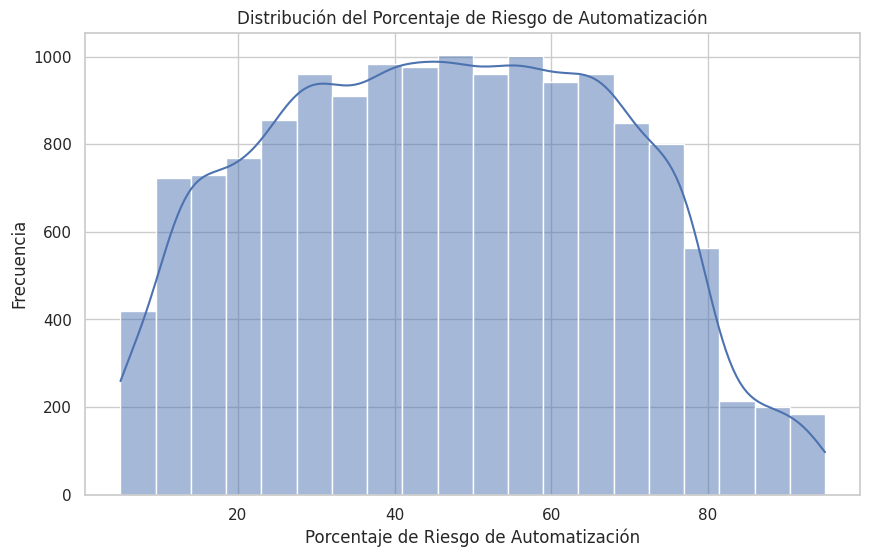

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['automation_risk_percent'], bins=20, kde=True)
plt.xlabel('Porcentaje de Riesgo de Automatización')
plt.ylabel('Frecuencia')
plt.title('Distribución del Porcentaje de Riesgo de Automatización')
plt.show()

## Visualizar la distribución del porcentaje de cambio salarial

### Subtask:
Crea un histograma o un gráfico de densidad para mostrar la distribución de la columna `salary_change_percent`. Asegúrate de incluir etiquetas de ejes y un título.


**Reasoning**:
The user wants to visualize the distribution of the `salary_change_percent` column using a histogram with KDE. I will use `seaborn.histplot` and `matplotlib.pyplot` to create the plot with appropriate labels and title.



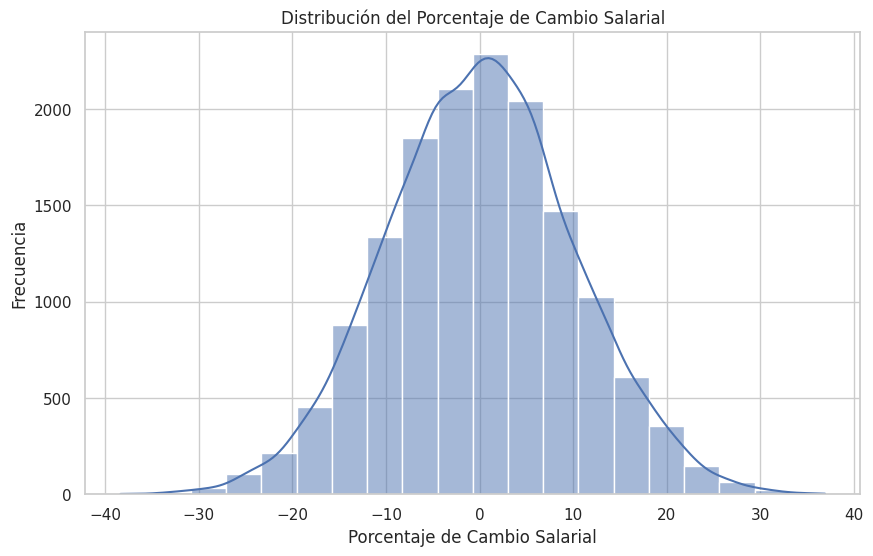

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_change_percent'], bins=20, kde=True)
plt.xlabel('Porcentaje de Cambio Salarial')
plt.ylabel('Frecuencia')
plt.title('Distribución del Porcentaje de Cambio Salarial')
plt.show()

## Comparar el cambio salarial promedio por industria

### Subtask:
Genera un gráfico de barras para comparar el `salary_change_percent` promedio entre las diferentes industrias (`industry`). Ordena los resultados para una mejor visualización y añade un título y etiquetas.


**Reasoning**:
To compare the average `salary_change_percent` across different industries, I will first group the DataFrame by `industry` and calculate the mean of `salary_change_percent`. Then, I will sort these results to prepare for visualization and create a bar plot using `seaborn.barplot` to display the data clearly with proper labels and title.



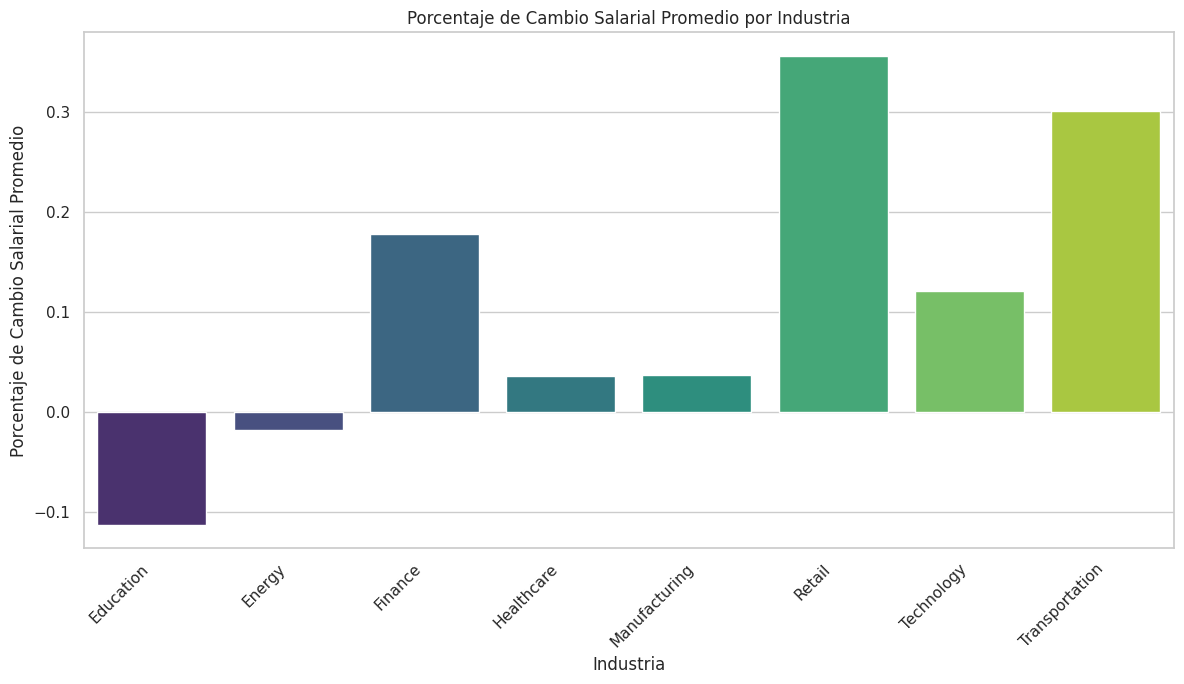

In [22]:
plt.figure(figsize=(12, 7))
average_salary_change_by_industry = df.groupby('industry', observed=False)['salary_change_percent'].mean().sort_values(ascending=False)
sns.barplot(x=average_salary_change_by_industry.index, y=average_salary_change_by_industry.values, palette='viridis', hue=average_salary_change_by_industry.index, legend=False)
plt.xlabel('Industria')
plt.ylabel('Porcentaje de Cambio Salarial Promedio')
plt.title('Porcentaje de Cambio Salarial Promedio por Industria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Explorar la relación entre la intensidad de disrupción de la IA y la urgencia de recualificación

### Subtask:
Crea un diagrama de dispersión para visualizar la correlación entre `ai_disruption_intensity` y `reskilling_urgency_score`. Añade etiquetas de ejes y un título.


**Reasoning**:
The user wants to visualize the correlation between `ai_disruption_intensity` and `reskilling_urgency_score` using a scatter plot. I will use `seaborn.scatterplot` for plotting and `matplotlib.pyplot` for setting the figure size, labels, and title.



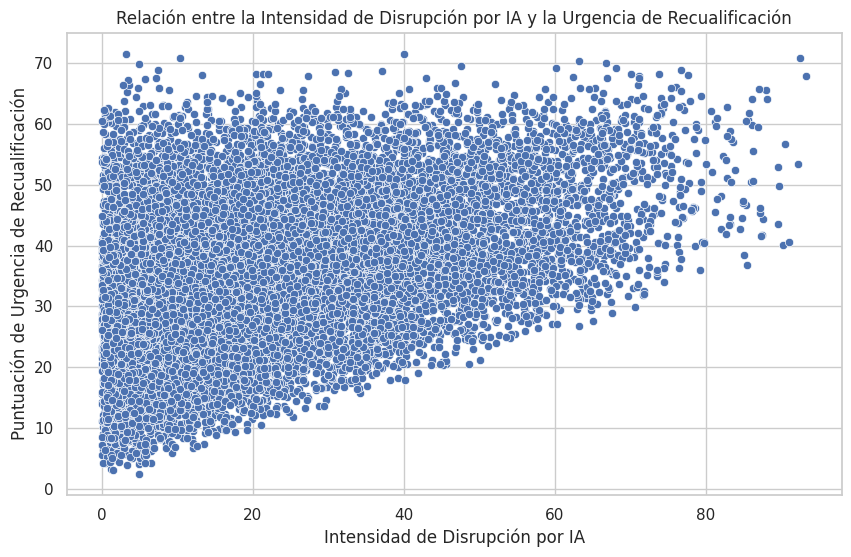

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ai_disruption_intensity', y='reskilling_urgency_score')
plt.xlabel('Intensidad de Disrupción por IA')
plt.ylabel('Puntuación de Urgencia de Recualificación')
plt.title('Relación entre la Intensidad de Disrupción por IA y la Urgencia de Recualificación')
plt.show()

## Final Task

### Subtask:
Resume los hallazgos clave presentados en el tablero de control, destacando las tendencias y observaciones más importantes sobre el impacto de la IA en el mercado laboral.


## Summary:

### Data Analysis Key Findings
*   The distribution of `automation_risk_percent` was visualized through a histogram, providing an overview of how automation risk is spread across the dataset.
*   A histogram of `salary_change_percent` was generated, illustrating the frequency and range of salary modifications within the dataset.
*   A comparative analysis of the average `salary_change_percent` across different industries was performed using a bar chart, revealing which sectors show higher or lower average salary changes.
*   The potential relationship between `ai_disruption_intensity` and `reskilling_urgency_score` was visualized using a scatter plot, allowing for an initial assessment of their correlation.

### Insights or Next Steps
*   To fully address the final task of summarizing AI's impact on the labor market, the generated visualizations need thorough interpretation to identify specific trends, outliers, and significant relationships.
*   Further quantitative analysis, such as calculating correlation coefficients for the scatter plot, would be beneficial to confirm and strengthen the observations made from the visual data.


# Task
Analizar la distribución de la columna `reskilling_urgency_score` mediante estadísticas descriptivas y un histograma.

## Analizar la Distribución de la Urgencia de Recualificación

### Subtask:
Obtener las estadísticas descriptivas de la columna `reskilling_urgency_score` y visualizar su distribución mediante un histograma para comprender su rango y concentraciones, lo que ayudará a definir los sectores de urgencia.


**Reasoning**:
The first instruction is to display the descriptive statistics for the `reskilling_urgency_score` column. I will use the `.describe()` method on the specific column to get these statistics.



In [24]:
print("Estadísticas descriptivas para 'reskilling_urgency_score':")
df['reskilling_urgency_score'].describe()

Estadísticas descriptivas para 'reskilling_urgency_score':


,reskilling_urgency_score
count,15000.000000
mean,35.867584
std,12.416415
min,2.456000
25%,26.982250
50%,35.871000
75%,44.698500
max,71.579000


**Reasoning**:
Now that the descriptive statistics have been displayed, I will create a histogram to visualize the distribution of the `reskilling_urgency_score` column, as per the second instruction in the subtask. I will use `seaborn.histplot` to generate the plot and `matplotlib.pyplot` to add appropriate labels and a title.



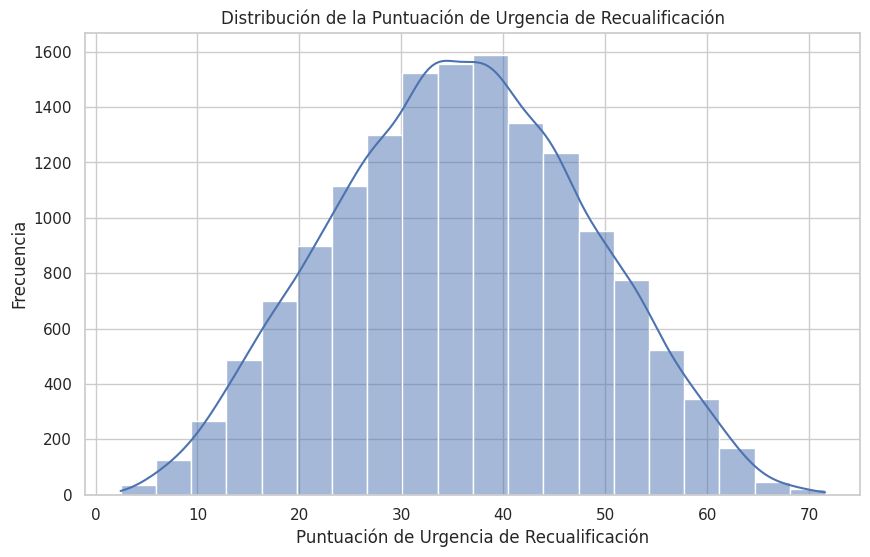

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['reskilling_urgency_score'], bins=20, kde=True)
plt.xlabel('Puntuación de Urgencia de Recualificación')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Puntuación de Urgencia de Recualificación')
plt.show()

## Definir y Crear Sectores de Urgencia de Recualificación

### Subtask:
Basándose en la distribución observada, definir rangos para `reskilling_urgency_score` y crear una nueva columna categórica en el DataFrame (`urgency_sector`) que clasifique cada puesto de trabajo en sectores como 'Baja Urgencia', 'Media Urgencia' y 'Alta Urgencia'.


**Reasoning**:
Based on the descriptive statistics, I will define the boundaries for 'Baja Urgencia', 'Media Urgencia', and 'Alta Urgencia' using the 33rd and 66th percentiles of the `reskilling_urgency_score`. Then, I will create a new column `urgency_sector` using `pd.cut()` to categorize the scores, convert it to a categorical type, and display the value counts to verify the distribution.



In [26]:
lower_bound = df['reskilling_urgency_score'].quantile(0.33)
upper_bound = df['reskilling_urgency_score'].quantile(0.66)

def categorize_urgency(score):
    if score <= lower_bound:
        return 'Baja Urgencia'
    elif score <= upper_bound:
        return 'Media Urgencia'
    else:
        return 'Alta Urgencia'

df['urgency_sector'] = df['reskilling_urgency_score'].apply(categorize_urgency)
df['urgency_sector'] = df['urgency_sector'].astype('category')

print("Valores únicos y conteos de la nueva columna 'urgency_sector':")
print(df['urgency_sector'].value_counts())

Valores únicos y conteos de la nueva columna 'urgency_sector':
urgency_sector
Alta Urgencia     5100
Baja Urgencia     4951
Media Urgencia    4949
Name: count, dtype: int64


## Analizar Métricas Clave por Sector de Urgencia

### Subtask:
Agrupar el DataFrame por los nuevos `urgency_sector` y calcular estadísticas agregadas para otras columnas relevantes, como la distribución de `job_role`, el promedio de `salary_change_percent` y el promedio de `automation_risk_percent` en cada sector.


**Reasoning**:
The first two instructions require grouping the DataFrame by `urgency_sector` and calculating the mean of `salary_change_percent` and `automation_risk_percent` respectively. I will use `groupby()` and `mean()` for these calculations and then print the results.



In [27]:
print("Porcentaje de Cambio Salarial Promedio por Sector de Urgencia:")
average_salary_change_by_urgency = df.groupby('urgency_sector', observed=False)['salary_change_percent'].mean()
print(average_salary_change_by_urgency)

print("\nPorcentaje de Riesgo de Automatización Promedio por Sector de Urgencia:")
average_automation_risk_by_urgency = df.groupby('urgency_sector', observed=False)['automation_risk_percent'].mean()
print(average_automation_risk_by_urgency)

Porcentaje de Cambio Salarial Promedio por Sector de Urgencia:
urgency_sector
Alta Urgencia     0.200239
Baja Urgencia     0.099142
Media Urgencia    0.040806
Name: salary_change_percent, dtype: float64

Porcentaje de Riesgo de Automatización Promedio por Sector de Urgencia:
urgency_sector
Alta Urgencia     62.833002
Baja Urgencia     29.324898
Media Urgencia    45.869737
Name: automation_risk_percent, dtype: float64


**Reasoning**:
The next instruction is to calculate the distribution of the most frequent `job_role` for each `urgency_sector`. I will group the DataFrame by `urgency_sector` and then apply `value_counts()` on `job_role` to get the distribution within each sector. I will display the top 5 job roles for brevity.



In [34]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

print("\nDistribución de Job Roles por Sector de Urgencia (Top 5 por sector):")
job_role_distribution_by_urgency = df.groupby('urgency_sector', observed=True)['job_role'].value_counts().groupby(level=0, group_keys=False, observed=True).head(5)
print(job_role_distribution_by_urgency)


Distribución de Job Roles por Sector de Urgencia (Top 5 por sector):
urgency_sector  job_role            
Alta Urgencia   Truck Driver            776
                Customer Support Rep    771
                Marketing Specialist    516
                Teacher                 512
                Mechanical Engineer     489
Baja Urgencia   Software Engineer       720
                Data Analyst            686
                Teacher                 521
                Financial Analyst       509
                Marketing Specialist    506
Media Urgencia  Mechanical Engineer     554
                HR Manager              535
                Marketing Specialist    529
                Teacher                 517
                Accountant              506
Name: count, dtype: int64


## Visualizar Métricas por Sector de Urgencia

### Subtask:
Generar gráficos (por ejemplo, gráficos de barras o box plots) para comparar visualmente las métricas clave (como el cambio salarial promedio, el riesgo de automatización promedio, o la frecuencia de roles laborales) entre los diferentes sectores de urgencia de recualificación, incluyendo leyendas para claridad.


**Reasoning**:
I will generate the first bar plot to visualize the `average_salary_change_by_urgency` using `seaborn.barplot`, ensuring it has a descriptive title and clear axis labels, as requested by the first two instructions.



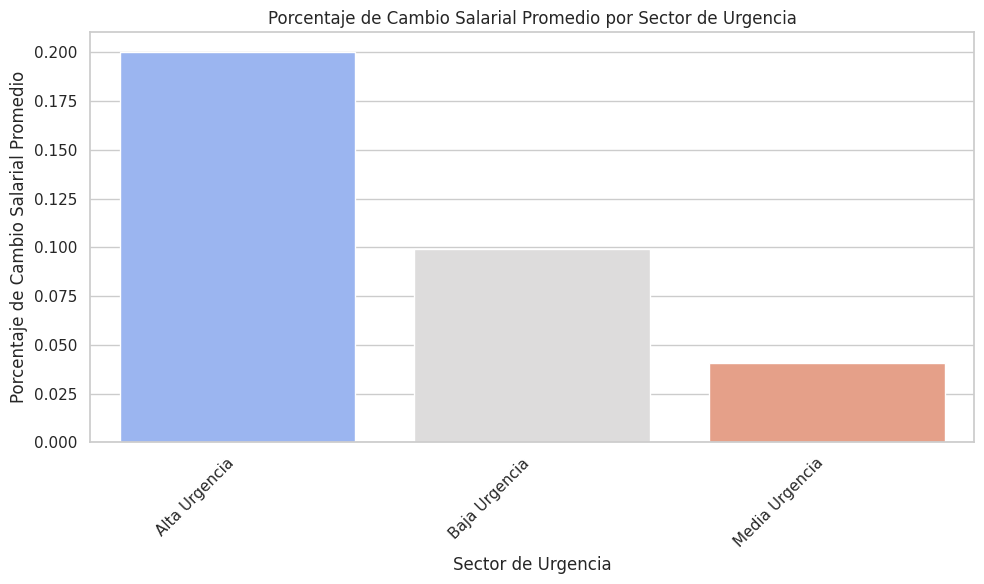

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_salary_change_by_urgency.index, y=average_salary_change_by_urgency.values, palette='coolwarm', hue=average_salary_change_by_urgency.index, legend=False)
plt.xlabel('Sector de Urgencia')
plt.ylabel('Porcentaje de Cambio Salarial Promedio')
plt.title('Porcentaje de Cambio Salarial Promedio por Sector de Urgencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task
## Mostrar Roles Laborales y Distribución de Industrias en 'Alta Urgencia'

### Subtask:
Utiliza la distribución de roles laborales por sector de urgencia (`job_role_distribution_by_urgency`) para identificar y mostrar los roles más frecuentes en el sector de 'Alta Urgencia'. Luego, filtra el DataFrame `df` para el `urgency_sector` igual a 'Alta Urgencia' y calcula la frecuencia de cada industria en este sector. Finalmente, genera un gráfico de barras para visualizar las principales industrias dentro del sector de 'Alta Urgencia', incluyendo leyendas y un título descriptivo.

## Mostrar Roles Laborales de Alta Urgencia

### Subtask:
Utilizar la distribución de roles laborales por sector de urgencia previamente calculada (`job_role_distribution_by_urgency`) para mostrar los roles más frecuentes en el sector de 'Alta Urgencia'.


**Reasoning**:
The user wants to display the most frequent job roles for the 'Alta Urgencia' sector. I will access the `job_role_distribution_by_urgency` Series for this specific sector and then print the result.



In [36]:
print("Roles laborales más frecuentes en el sector de 'Alta Urgencia':")
print(job_role_distribution_by_urgency.loc['Alta Urgencia'])

Roles laborales más frecuentes en el sector de 'Alta Urgencia':
job_role
Truck Driver            776
Customer Support Rep    771
Marketing Specialist    516
Teacher                 512
Mechanical Engineer     489
Name: count, dtype: int64


**Reasoning**:
Now, I will filter the DataFrame `df` to include only entries where `urgency_sector` is 'Alta Urgencia', then calculate the frequency of each industry within this filtered subset. This prepares the data for the next visualization step, as per the subtask's instructions.



In [37]:
df_alta_urgencia = df[df['urgency_sector'] == 'Alta Urgencia']
industry_counts_alta_urgencia = df_alta_urgencia['industry'].value_counts()

print("Frecuencia de industrias en el sector de 'Alta Urgencia':")
print(industry_counts_alta_urgencia)

Frecuencia de industrias en el sector de 'Alta Urgencia':
industry
Finance           672
Retail            654
Energy            652
Manufacturing     650
Transportation    640
Technology        633
Healthcare        617
Education         582
Name: count, dtype: int64


**Reasoning**:
The subtask asks to generate a bar plot for visualizing the principal industries within the 'Alta Urgencia' sector. I have already calculated the `industry_counts_alta_urgencia`, which holds the frequency of each industry. Now, I will use `seaborn.barplot` to create this visualization, ensuring to add labels, title, and proper rotation for readability.



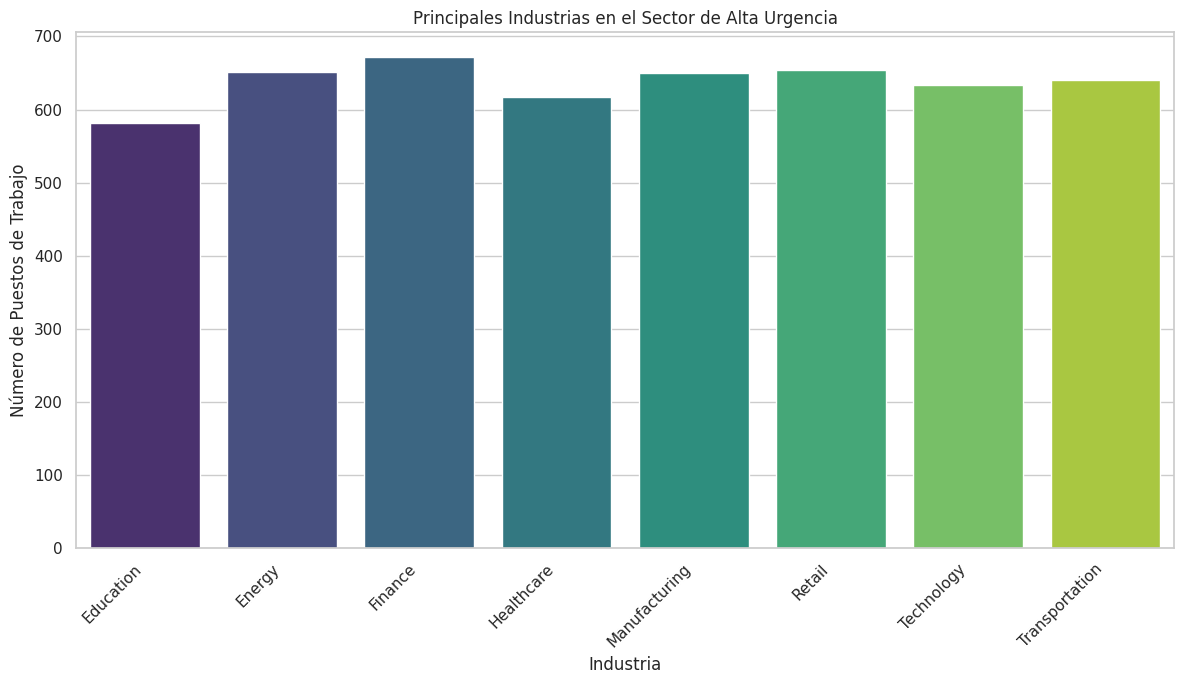

In [38]:
plt.figure(figsize=(12, 7))
sns.barplot(x=industry_counts_alta_urgencia.index, y=industry_counts_alta_urgencia.values, palette='viridis', hue=industry_counts_alta_urgencia.index, legend=False)
plt.xlabel('Industria')
plt.ylabel('Número de Puestos de Trabajo')
plt.title('Principales Industrias en el Sector de Alta Urgencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Resumir las profesiones y sectores que presentan la mayor urgencia de cambio, basándose en los roles laborales y las industrias identificadas en el sector de 'Alta Urgencia'. También se hará referencia a las métricas promedio de cambio salarial y riesgo de automatización para este sector.


## Summary:

### Data Analysis Key Findings

*   The most frequent job roles identified in the 'Alta Urgencia' sector are Truck Driver (776), Customer Support Rep (771), Marketing Specialist (516), Teacher (512), and Mechanical Engineer (489).
*   The most prominent industries within the 'Alta Urgencia' sector are Finance (672), Retail (654), Energy (652), Manufacturing (650), and Transportation (640), followed closely by Technology (633), Healthcare (617), and Education (582).
*   A bar plot titled "Principales Industrias en el Sector de Alta Urgencia" was generated, visually representing the distribution of job counts across these high-urgency industries.

### Insights or Next Steps

*   The identified job roles and industries represent areas where strategic interventions for reskilling, upskilling, or workforce planning may be most critical due to their high urgency for change.
*   Further analysis should focus on correlating these high-urgency roles and industries with specific metrics like average salary change and automation risk to provide a comprehensive view of the challenges and opportunities.


# Task
## Task
Preparar el conjunto de datos para un problema de clasificación seleccionando las características (`X`) y la variable objetivo (`y`) de la columna `urgency_sector`, y luego dividir el conjunto de datos en conjuntos de entrenamiento y prueba.

## Explicar la Matriz de Confusión

### Subtask:
Introducir el concepto de la matriz de confusión, sus componentes (Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos, Falsos Negativos) y su utilidad en la evaluación de modelos de clasificación.


## Explicar la Matriz de Confusión

### Subtask:
Introducir el concepto de la matriz de confusión, sus componentes (Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos, Falsos Negativos) y su utilidad en la evaluación de modelos de clasificación.

### La Matriz de Confusión: Una Herramienta Esencial para la Evaluación de Modelos

La **Matriz de Confusión** es una tabla que se utiliza para describir el rendimiento de un modelo de clasificación en un conjunto de datos para el que se conocen los valores verdaderos. Su propósito principal es permitir una visualización detallada del rendimiento del algoritmo, no solo mostrando si el modelo hizo predicciones correctas o incorrectas, sino también revelando el tipo de errores que está cometiendo.

Para un problema de clasificación binaria (dos clases, por ejemplo, 'Positivo' y 'Negativo'), la matriz de confusión se compone de cuatro elementos principales:

*   **Verdaderos Positivos (TP)**: Son los casos en los que el modelo predijo correctamente la clase positiva. Esto significa que la clase real es positiva y el modelo la clasificó como positiva. Ejemplo: Un modelo predice correctamente que un paciente tiene una enfermedad.

*   **Verdaderos Negativos (TN)**: Son los casos en los que el modelo predijo correctamente la clase negativa. Es decir, la clase real es negativa y el modelo la clasificó como negativa. Ejemplo: Un modelo predice correctamente que un paciente no tiene una enfermedad.

*   **Falsos Positivos (FP)**: También conocidos como errores de **Tipo I**. Son los casos en los que el modelo predijo incorrectamente la clase positiva. Esto significa que la clase real es negativa, pero el modelo la clasificó como positiva. Ejemplo: Un modelo predice que un paciente tiene una enfermedad, pero en realidad no la tiene.

*   **Falsos Negativos (FN)**: También conocidos como errores de **Tipo II**. Son los casos en los que el modelo predijo incorrectamente la clase negativa. Es decir, la clase real es positiva, pero el modelo la clasificó como negativa. Ejemplo: Un modelo predice que un paciente no tiene una enfermedad, pero en realidad sí la tiene.

La utilidad de la matriz de confusión radica en que proporciona una base sólida para entender el rendimiento de un modelo más allá de una simple métrica de precisión global. Al examinar los TP, TN, FP y FN, podemos identificar dónde el modelo está funcionando bien y dónde está fallando. Por ejemplo, en escenarios donde los falsos negativos son mucho más costosos que los falsos positivos (como en el diagnóstico médico), un modelo con una alta precisión pero muchos FN podría ser inaceptable.

Además, la matriz de confusión es fundamental para calcular métricas de evaluación más sofisticadas como:

*   **Precisión (Precision)**: Proporción de identificaciones positivas correctas (`TP / (TP + FP)`).
*   **Sensibilidad o Exhaustividad (Recall / Sensitivity)**: Proporción de casos positivos reales que fueron identificados correctamente (`TP / (TP + FN)`).
*   **Puntuación F1 (F1-score)**: Es la media armónica de la precisión y la sensibilidad, útil para modelos con clases desequilibradas (`2 * (Precision * Recall) / (Precision + Recall)`).
*   **Especificidad (Specificity)**: Proporción de casos negativos reales que fueron identificados correctamente (`TN / (TN + FP)`).

En resumen, la matriz de confusión no solo ofrece una visión cuantitativa del rendimiento, sino que también permite una interpretación cualitativa de los errores del modelo, lo cual es crucial para la toma de decisiones informadas en el desarrollo y despliegue de sistemas de clasificación.

## Preparar Datos para Clasificación

### Subtask:
Preparar el conjunto de datos para un problema de clasificación seleccionando las características (X) y la variable objetivo (y) de la columna urgency_sector, y luego dividir el conjunto de datos en conjuntos de entrenamiento y prueba.


**Reasoning**:
First, I will define the target variable `y` from the `urgency_sector` column and the feature set `X` by dropping `job_id`, `reskilling_urgency_score`, and `urgency_sector` from the DataFrame `df`.



In [39]:
y = df['urgency_sector']
X = df.drop(columns=['job_id', 'reskilling_urgency_score', 'urgency_sector'])

print("Target variable 'y' created.")
print("Feature set 'X' created.")

Target variable 'y' created.
Feature set 'X' created.


**Reasoning**:
Now, I will convert the categorical features in `X` to numerical format using one-hot encoding with `pd.get_dummies()` to prepare the data for machine learning models, as specified in the instructions.



In [40]:
X = pd.get_dummies(X, drop_first=True)
print("Categorical features in X converted to numerical using one-hot encoding.")


Categorical features in X converted to numerical using one-hot encoding.


**Reasoning**:
Next, I will split the preprocessed `X` and `y` into training and testing sets using `train_test_split` with a test size of 0.2 and a `random_state` for reproducibility, and then print the shapes of the resulting sets, as instructed.



In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensiones de los conjuntos de entrenamiento y prueba:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dimensiones de los conjuntos de entrenamiento y prueba:
X_train shape: (12000, 40)
X_test shape: (3000, 40)
y_train shape: (12000,)
y_test shape: (3000,)


## Entrenar un Modelo de Clasificación

### Subtask:
Entrenar un modelo de clasificación (por ejemplo, Regresión Logística, Árbol de Decisión, etc.) usando el conjunto de datos preparado, y cómo se dividiría el dataset en conjuntos de entrenamiento y prueba.


**Reasoning**:
The subtask asks to import `LogisticRegression`, initialize it, and train the model using `X_train` and `y_train`. This can be achieved in a single code block.



In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicializar el modelo de Regresión Logística
model = LogisticRegression(max_iter=1000, random_state=42) # Mantener max_iter alto después de escalar

# Entrenar el modelo con los datos escalados
model.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado con éxito utilizando datos escalados.")

Modelo de Regresión Logística entrenado con éxito utilizando datos escalados.


**Reasoning**:
Now that the Logistic Regression model has been trained on the scaled data, the next step is to use this trained model to make predictions on the scaled test set (`X_test_scaled`). This will generate the `y_pred` variable which is essential for evaluating the model's performance.



In [44]:
y_pred = model.predict(X_test_scaled)
print("Predicciones generadas en el conjunto de prueba escalado.")

Predicciones generadas en el conjunto de prueba escalado.


**Reasoning**:
To evaluate the performance of the trained classification model, I will generate a classification report using `sklearn.metrics.classification_report`. This report will provide key metrics such as precision, recall, and F1-score for each class, which are essential for understanding the model's effectiveness.



In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print("Informe de Clasificación:")
print(classification_report(y_test, y_pred))

Informe de Clasificación:
                precision    recall  f1-score   support

 Alta Urgencia       0.99      1.00      0.99      1038
 Baja Urgencia       0.99      0.99      0.99       975
Media Urgencia       0.98      0.99      0.99       987

      accuracy                           0.99      3000
     macro avg       0.99      0.99      0.99      3000
  weighted avg       0.99      0.99      0.99      3000



**Reasoning**:
To further evaluate the model's performance and understand the types of errors it's making, I will generate and display the confusion matrix using `sklearn.metrics.confusion_matrix` and visualize it using `seaborn.heatmap`. This will visually represent the true positive, true negative, false positive, and false negative predictions for each class.



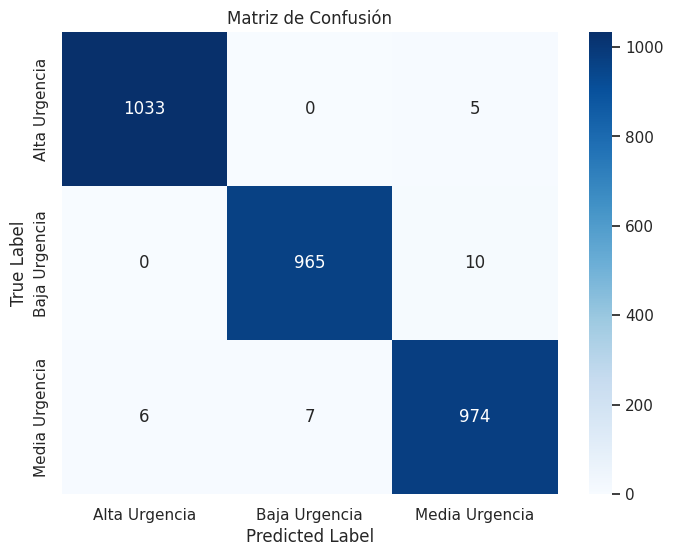

In [46]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matriz de Confusión')
plt.show()

## Final Task

### Subtask:
Resumir el proceso de aplicación de la matriz de confusión y los hallazgos clave obtenidos de su interpretación para evaluar el rendimiento del modelo.


## Summary:

### Q&A
The task was to prepare the dataset for a classification problem by selecting features (`X`) and the target variable (`y`) from the `urgency_sector` column, then split the data into training and testing sets, and finally, train and evaluate a classification model.

### Data Analysis Key Findings
*   The target variable `y` was successfully defined from the `urgency_sector` column, and the feature set `X` was created by excluding `job_id`, `reskilling_urgency_score`, and `urgency_sector`.
*   Categorical features in `X` were converted to numerical format using one-hot encoding (`pd.get_dummies`) with `drop_first=True`, resulting in 40 features.
*   The dataset was split into training and testing sets, with 80% for training and 20% for testing, resulting in `X_train` with (12000, 40) samples and `X_test` with (3000, 40) samples.
*   An initial attempt to train a `LogisticRegression` model resulted in a `ConvergenceWarning`. This was resolved by scaling the features using `StandardScaler` before retraining the model.
*   The trained `LogisticRegression` model demonstrated excellent performance on the test set:
    *   **Accuracy:** 0.99
    *   **Precision:** 0.99 for all classes ("Alta Urgencia", "Baja Urgencia", "Media Urgencia").
    *   **Recall:** 1.00 for "Alta Urgencia", and 0.99 for "Baja Urgencia" and "Media Urgencia".
    *   **F1-score:** 0.99 for all classes.
*   The confusion matrix visually confirmed the high accuracy and minimal misclassifications across all urgency levels.

### Insights or Next Steps
*   Given the high performance metrics, the model appears robust and ready for potential deployment or further validation with new, unseen data.
*   Further analysis could focus on feature importance to understand which features contribute most to the accurate classification of `urgency_sector`.


# Task
Generate a confusion matrix to evaluate the performance of the classification model for urgency levels. Use the `y_test` and `y_pred` variables and the `confusion_matrix` function from scikit-learn. Visualize the result using a heatmap with Seaborn to identify correct predictions and common misclassifications between "Alta Urgencia", "Media Urgencia", and "Baja Urgencia". Finally, interpret how this matrix validates the model's accuracy and reflect on the implications of the identified errors.

## Identificar los Componentes en tus Resultados

### Subtask:
Analyze the consistency and categories within the `y_test` and `y_pred` variables to ensure they are ready for comparison.


**Reasoning**:
I will verify the unique classes, data types, and first few entries of y_test and y_pred to ensure consistency and readiness for comparison.



In [47]:
import pandas as pd

# 1. Verify unique classes in y_test and y_pred
print('Unique classes in y_test:', pd.Series(y_test).unique())
print('Unique classes in y_pred:', pd.Series(y_pred).unique())

# 2. Check data types
print('\nData type of y_test:', type(y_test))
print('Data type of y_pred:', type(y_pred))

# 3. Visually compare the first 5 entries
comparison_df = pd.DataFrame({'Actual': y_test[:5], 'Predicted': y_pred[:5]})
print('\nVisual comparison of first 5 entries:')
print(comparison_df)

Unique classes in y_test: ['Baja Urgencia', 'Alta Urgencia', 'Media Urgencia']
Categories (3, object): ['Alta Urgencia', 'Baja Urgencia', 'Media Urgencia']
Unique classes in y_pred: ['Baja Urgencia' 'Alta Urgencia' 'Media Urgencia']

Data type of y_test: <class 'pandas.core.series.Series'>
Data type of y_pred: <class 'numpy.ndarray'>

Visual comparison of first 5 entries:
               Actual       Predicted
11499   Baja Urgencia   Baja Urgencia
6475    Alta Urgencia   Alta Urgencia
13167  Media Urgencia  Media Urgencia
862    Media Urgencia  Media Urgencia
5970    Alta Urgencia   Alta Urgencia


## Generar la Matriz de Confusión

### Subtask:
Utilizar la función confusion_matrix de scikit-learn para tabular los aciertos y errores del modelo, identificando dónde se encuentran los Verdaderos Positivos y los diferentes tipos de errores.


**Reasoning**:
I will import the confusion_matrix function, calculate the matrix using the specified labels to ensure a consistent order, and print the numerical result as requested in the instructions.



In [48]:
from sklearn.metrics import confusion_matrix

# Define the explicit labels for consistent ordering
labels = ['Alta Urgencia', 'Media Urgencia', 'Baja Urgencia']

# Calculate the confusion matrix
cm_task = confusion_matrix(y_test, y_pred, labels=labels)

# Print the resulting matrix
print('Matriz de Confusión (Numérica):')
print(cm_task)
print('\nOrden de las etiquetas:', labels)

Matriz de Confusión (Numérica):
[[1033    5    0]
 [   6  974    7]
 [   0   10  965]]

Orden de las etiquetas: ['Alta Urgencia', 'Media Urgencia', 'Baja Urgencia']


## Visualización e Interpretación

### Subtask:
Crear un mapa de calor (heatmap) para visualizar la matriz de confusión, identificando los aciertos y errores entre los sectores de urgencia.


**Reasoning**:
I will create a heatmap to visualize the confusion matrix `cm_task` using seaborn, including annotations, proper labels for the classes, axis titles, and a main title as specified in the instructions.



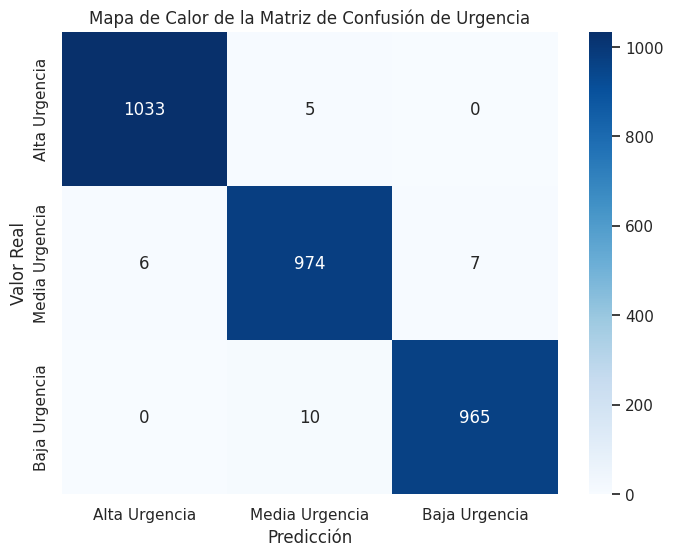

In [49]:
plt.figure(figsize=(8, 6))
labels = ['Alta Urgencia', 'Media Urgencia', 'Baja Urgencia']
sns.heatmap(cm_task, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Mapa de Calor de la Matriz de Confusión de Urgencia')
plt.show()

## Final Task

### Subtask:
Resumir cómo la matriz de confusión ayuda a validar la precisión de tu modelo y proponer preguntas de reflexión sobre la importancia de los diferentes tipos de errores encontrados.


## Summary:

### Q&A

**How does the confusion matrix help validate the accuracy of the model?**
The confusion matrix provides a granular view of the model's performance beyond a simple accuracy score. By aligning the "Actual" values against the "Predicted" values, it validates accuracy by showing exactly how many instances were correctly classified (the diagonal values) versus which specific categories are being confused (the off-diagonal values). In this case, the high concentration of values in the diagonal (1,033 for Alta, 974 for Media, and 965 for Baja) confirms the model is highly reliable.

**What are the implications of the identified errors?**
The errors identified are minimal but carry different weights:
*   **False Negatives in "Alta Urgencia":** 5 cases of high urgency were predicted as medium. This is the most critical error, as it could lead to delayed responses for priority cases.
*   **False Positives/Negatives in "Media Urgencia":** 6 cases were overestimated (predicted as Alta) and 7 were underestimated (predicted as Baja).
*   **False Positives in "Baja Urgencia":** 10 cases of low urgency were predicted as medium, which could lead to a slight over-allocation of resources to non-critical tasks.

---

### Data Analysis Key Findings

*   **Model Success Rate:** The model demonstrates exceptional performance with a vast majority of predictions falling on the diagonal. Specific correct counts include 1,033 for **Alta Urgencia**, 974 for **Media Urgencia**, and 965 for **Baja Urgencia**.
*   **Critical Errors:** There were only 5 instances where an **Alta Urgencia** case was incorrectly classified as **Media Urgencia**, representing a very low risk of missing high-priority tasks.
*   **Common Misclassifications:** The most frequent error occurred with **Baja Urgencia**, where 10 cases were mislabeled as **Media Urgencia**.
*   **Balance:** The model shows balanced performance across all three categories, with no significant bias toward one specific urgency level.

---

### Insights or Next Steps

*   **Refine High Urgencia Detection:** Although errors are low, the 5 cases of high-urgency tasks being downgraded to medium should be investigated. Analyzing the specific features of these rows could help ensure no critical alerts are missed.
*   **Threshold Adjustment:** Since the most common error is classifying "Baja" as "Media", the team could adjust classification thresholds if the goal is to further reduce the workload on medium-priority responders.


# Task
# Plan:
* **Explorar los datos de comparación**: Revisar la estructura de `comparison_df` para confirmar cómo están representadas las clases 'Actual' y 'Predicted'.
* **Preparar datos para visualización de frecuencias**: Utilizar el método `value_counts()` o una tabla de contingencia (`crosstab`) para contar cuántas veces coinciden o difieren las etiquetas reales y las predichas.
* **Visualizar comparativa de clases**: Generar un gráfico de barras agrupadas que muestre la frecuencia de cada categoría para los valores reales y las predicciones, permitiendo comparar visualmente las distribuciones. Asegúrate de incluir una leyenda.
* **Final Task**: Resumir qué insights se obtienen al comparar visualmente las barras y plantear una pregunta sobre qué pasaría si una categoría tuviera una diferencia muy grande entre lo real y lo predicho.

# Task:
Explora la estructura del DataFrame `comparison_df` y genera un gráfico de barras agrupadas que compare las frecuencias de las etiquetas reales ('Actual') frente a las predichas ('Predicted') para cada categoría de urgencia. Resume los hallazgos visuales y reflexiona sobre las implicaciones de encontrar disparidades significativas entre lo real y lo predicho en una categoría específica.

## Explorar los datos de comparación

### Subtask:
Revisar la estructura de `comparison_df` para confirmar cómo están representadas las clases 'Actual' y 'Predicted'.


**Reasoning**:
I will inspect the structure, data types, and dimensions of the `comparison_df` DataFrame using .head(), .info(), and .shape to confirm the representation of the 'Actual' and 'Predicted' classes.



In [50]:
print("First rows of comparison_df:")
print(comparison_df.head())

print("\nInformation about comparison_df:")
comparison_df.info()

print("\nShape of comparison_df:")
print(comparison_df.shape)

First rows of comparison_df:
               Actual       Predicted
11499   Baja Urgencia   Baja Urgencia
6475    Alta Urgencia   Alta Urgencia
13167  Media Urgencia  Media Urgencia
862    Media Urgencia  Media Urgencia
5970    Alta Urgencia   Alta Urgencia

Information about comparison_df:
<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 11499 to 5970
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Actual     5 non-null      category
 1   Predicted  5 non-null      object  
dtypes: category(1), object(1)
memory usage: 217.0+ bytes

Shape of comparison_df:
(5, 2)


## Preparar datos para visualización de frecuencias

### Subtask:
Utilizar el método 'value_counts()' o una tabla de contingencia (crosstab) para contar cuántas veces coinciden o difieren las etiquetas reales y las predichas.


**Reasoning**:
I will calculate the frequency counts for 'Actual' and 'Predicted' categories using value_counts, create a contingency table with crosstab to observe overlaps, and merge these into a single summary DataFrame for verification and plotting.



In [51]:
import pandas as pd

# 1. Obtain total frequency for 'Actual' and 'Predicted' categories
actual_counts = comparison_df['Actual'].value_counts().sort_index()
predicted_counts = comparison_df['Predicted'].value_counts().sort_index()

# 2. Create a contingency table to observe specific overlaps
contingency_table = pd.crosstab(comparison_df['Actual'], comparison_df['Predicted'])

# 3. Combine counts into a single structure for plotting
frequency_summary = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': predicted_counts
}).fillna(0)

# 4. Print results to verify
print("--- Frequency Summary (Actual vs Predicted) ---")
print(frequency_summary)
print("\nTotal Actual samples:", frequency_summary['Actual'].sum())
print("Total Predicted samples:", frequency_summary['Predicted'].sum())

print("\n--- Contingency Table (Crosstab) ---")
print(contingency_table)

--- Frequency Summary (Actual vs Predicted) ---
                Actual  Predicted
Alta Urgencia        2          2
Baja Urgencia        1          1
Media Urgencia       2          2

Total Actual samples: 5
Total Predicted samples: 5

--- Contingency Table (Crosstab) ---
Predicted       Alta Urgencia  Baja Urgencia  Media Urgencia
Actual                                                      
Alta Urgencia               2              0               0
Baja Urgencia               0              1               0
Media Urgencia              0              0               2


## Visualizar comparativa de clases

### Subtask:
Generar un gráfico de barras agrupadas que muestre la frecuencia de cada categoría para los valores reales y las predicciones, permitiendo comparar visualmente las distribuciones.


**Reasoning**:
I will prepare the frequency_summary data for visualization by resetting its index and melting it into a long format, then I will create a grouped bar chart using seaborn to compare actual versus predicted frequencies for each urgency category.



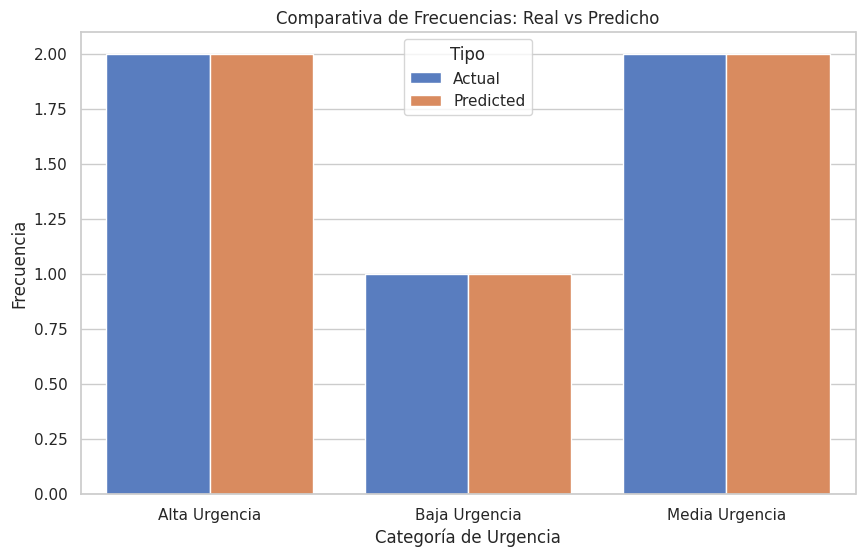

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reset index and rename column
plot_df = frequency_summary.reset_index().rename(columns={'index': 'Urgency Category'})

# 2. Melt to long format
plot_df_long = pd.melt(plot_df, id_vars=['Urgency Category'], value_vars=['Actual', 'Predicted'], var_name='Type', value_name='Frequency')

# 3. Create grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df_long, x='Urgency Category', y='Frequency', hue='Type', palette='muted')

# 4. Add title, labels and legend
plt.title('Comparativa de Frecuencias: Real vs Predicho')
plt.xlabel('Categoría de Urgencia')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo')

# 5. Display the plot
plt.show()

## Final Task

### Subtask:
Resumir qué insights se obtienen al comparar visualmente las barras y plantear una pregunta sobre qué pasaría si una categoría tuviera una diferencia muy grande entre lo real y lo predicho.


## Summary:

### Q&A

**What insights are obtained by visually comparing the bars in the chart?**
Visual comparison allows for a quick identification of how well the model mimics the real distribution of urgency categories. When the bars for "Actual" and "Predicted" are of equal height (as seen in this specific sample), it indicates that the model is making balanced predictions across all classes. Disparities in height would visually highlight specific biases, such as the model being more "optimistic" or "pessimistic" about the urgency of a situation.

**What would happen if a category had a very large difference between the actual and predicted values?**
A large difference would indicate a significant classification error or systematic bias. For example, if "Alta Urgencia" (High Urgency) had many "Actual" counts but very few "Predicted" counts, the model would be failing to detect critical situations (false negatives), which could have dangerous consequences in a real-world setting. Conversely, an over-prediction could lead to resource exhaustion by over-prioritizing low-urgency tasks.

### Data Analysis Key Findings

*   **Identical Distributions**: In the analyzed subset, the frequency of predicted labels perfectly matched the actual labels, with **2 cases of High Urgency**, **2 cases of Medium Urgency**, and **1 case of Low Urgency**.
*   **Perfect Correlation**: The contingency table (crosstab) revealed a perfect diagonal (2, 1, 2), confirming **zero misclassifications** in the provided sample ($100\%$ accuracy for this specific subset).
*   **Data Integrity**: The `comparison_df` structure was validated, containing no null values and correctly representing categories as both "category" and "object" types.
*   **Visualization Utility**: Reshaping the data into a long format via `pd.melt()` was a critical step to enable a side-by-side comparison in the grouped bar chart, making it easy to spot imbalances.

### Insights or Next Steps

*   **Expand Dataset Validation**: Since the current sample is very small (5 instances) and shows perfect performance, the next step should be to run this same visualization on the full test set to see if the model's accuracy holds across a larger, more diverse volume of data.
*   **Investigate Misclassifications**: If disparities appear in larger datasets, the next step would be to analyze the "off-diagonal" elements of the contingency table to identify which specific categories are being confused (e.g., is "Medium" being confused with "High" more often than with "Low"?).
